In [14]:
import numpy as np
import pandas as pd

import tensorflow as tf
import keras

from keras.models import Sequential
from keras.layers import Input, Dense

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    LabelEncoder,
    TargetEncoder, # Ensure you are using sklearn >= 1.3
    OneHotEncoder
)

In [15]:
# Load the dataset
data = pd.read_csv("../data/salary.csv")

# What type is this?
print(f"Type: {type(data)}")
print(f"Shape: {data.shape}  →  {data.shape[0]} rows, {data.shape[1]} columns")

Type: <class 'pandas.DataFrame'>
Shape: (30, 2)  →  30 rows, 2 columns


In [16]:
X = data.iloc[:, :-1].values    # All rows, all columns except last → Features
y = data.iloc[:, -1].values     # All rows, last column only → Target

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=42
)

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
model = Sequential([
    Input(shape=(1, )),
    Dense(units=1, activation='linear')
])

In [20]:
model.compile(optimizer="sgd", loss="mean_squared_error", metrics=["mae"])

In [32]:
history = model.fit(
    X_train_scaled,
    y_train, 
    epochs=100,
    validation_data=(X_test_scaled, y_test),
    verbose=1
)

Epoch 1/100


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 42217564.0000 - mae: 5390.5728 - val_loss: 69248488.0000 - val_mae: 6523.2314
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 41691100.0000 - mae: 5354.6304 - val_loss: 68268640.0000 - val_mae: 6482.9326
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 41185432.0000 - mae: 5319.4023 - val_loss: 67322304.0000 - val_mae: 6443.4419
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 40699840.0000 - mae: 5284.8838 - val_loss: 66408184.0000 - val_mae: 6404.7378
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 40233428.0000 - mae: 5251.0508 - val_loss: 65525184.0000 - val_mae: 6366.8096
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 39785528.0000 - mae: 5217.8975 - val_loss: 64672136.0000 - val_mae: 6329.6396
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 39355348.0000 - mae: 5185.4072 - val_loss: 63847972.0000 - val_mae: 6293.2134
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 38

In [33]:
# model.summary()

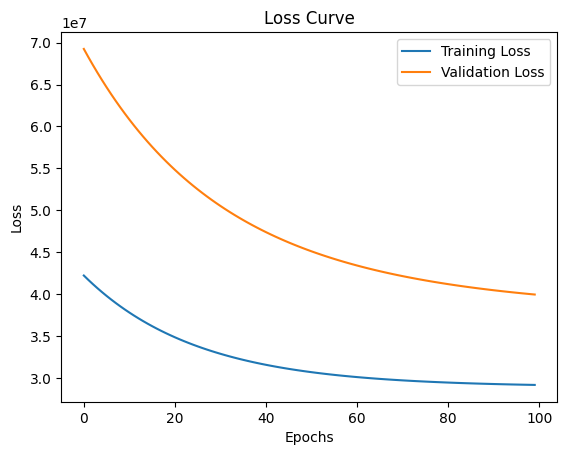

In [34]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.show()

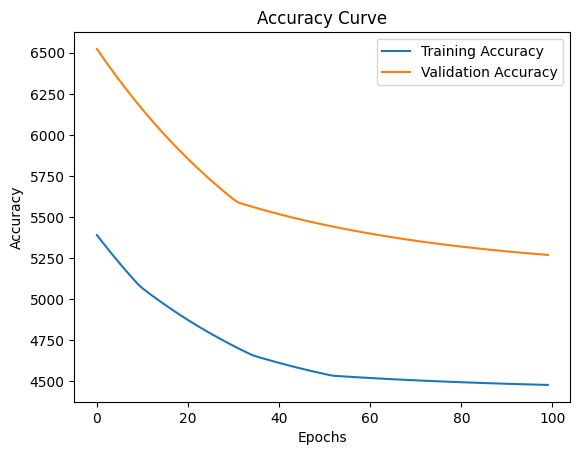

In [38]:
plt.plot(history.history['mae'], label='Training Accuracy')
plt.plot(history.history['val_mae'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

In [45]:
custom_input = np.array([[121872]])

In [46]:
custom_input_scaled = scaler.transform(custom_input)

In [47]:
prediction = model.predict(custom_input_scaled)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
[[1.1309082e+09]]
